In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip /content/drive/MyDrive/new_balanced_data.zip

Streaming output truncated to the last 5000 lines.
  inflating: new_balanced_data/Density3Malignant/augmented_82.jpg  
  inflating: new_balanced_data/Density3Malignant/augmented_822.jpg  
  inflating: new_balanced_data/Density3Malignant/augmented_824.jpg  
  inflating: new_balanced_data/Density3Malignant/augmented_826.jpg  
  inflating: new_balanced_data/Density3Malignant/augmented_827.jpg  
  inflating: new_balanced_data/Density3Malignant/augmented_829.jpg  
  inflating: new_balanced_data/Density3Malignant/augmented_83.jpg  
  inflating: new_balanced_data/Density3Malignant/augmented_833.jpg  
  inflating: new_balanced_data/Density3Malignant/augmented_834.jpg  
  inflating: new_balanced_data/Density3Malignant/augmented_835.jpg  
  inflating: new_balanced_data/Density3Malignant/augmented_838.jpg  
  inflating: new_balanced_data/Density3Malignant/augmented_839.jpg  
  inflating: new_balanced_data/Density3Malignant/augmented_841.jpg  
  inflating: new_balanced_data/Density3Malignant/augme

In [ ]:
from PIL import Image
import os

# Paths
input_dir = '/content/new_balanced_data'
output_dir = '/content/new_balanced_data_resized'

# Create output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Resize target
new_size = (299, 299)

# Loop through classes (subfolders)
for class_name in os.listdir(input_dir):
    class_path = os.path.join(input_dir, class_name)
    if not os.path.isdir(class_path):
        continue
    output_class_path = os.path.join(output_dir, class_name)
    os.makedirs(output_class_path, exist_ok=True)

    # Loop through images in class folder
    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        try:
            with Image.open(img_path) as img:
                # Resize image using LANCZOS (high-quality downsampling filter)
                img_resized = img.resize(new_size, Image.LANCZOS)
                # Save resized image
                img_resized.save(os.path.join(output_class_path, img_name))
        except Exception as e:
            print(f"Error processing {img_path}: {e}")

print("Resizing complete!")


Resizing complete!


In [ ]:
import os
import shutil
import random
from tqdm import tqdm

def split_dataset(dataset_dir, output_dir, train_ratio=0.7, val_ratio=0.2, test_ratio=0.1, seed=42):
    """Splits dataset into train, val, and test folders."""

    assert round(train_ratio + val_ratio + test_ratio, 2) == 1.0, "Ratios must sum to 1."

    random.seed(seed)

    if os.path.exists(output_dir):
        shutil.rmtree(output_dir)
    os.makedirs(output_dir, exist_ok=True)

    for split in ['train', 'val', 'test']:
        os.makedirs(os.path.join(output_dir, split), exist_ok=True)

    classes = [d for d in os.listdir(dataset_dir) if os.path.isdir(os.path.join(dataset_dir, d))]
    if not classes:
        raise ValueError(f"No class folders found in {dataset_dir}")

    for cls in tqdm(classes, desc='Processing classes'):
        class_dir = os.path.join(dataset_dir, cls)
        images = [f for f in os.listdir(class_dir) if os.path.isfile(os.path.join(class_dir, f))]

        if len(images) == 0:
            print(f"Warning: No images found in class folder {cls}, skipping.")
            continue

        random.shuffle(images)

        train_split = int(len(images) * train_ratio)
        val_split = int(len(images) * (train_ratio + val_ratio))

        train_files = images[:train_split]
        val_files = images[train_split:val_split]
        test_files = images[val_split:]

        for split_name, files in zip(['train', 'val', 'test'], [train_files, val_files, test_files]):
            split_dir = os.path.join(output_dir, split_name, cls)
            os.makedirs(split_dir, exist_ok=True)
            for file in files:
                shutil.copy2(os.path.join(class_dir, file), os.path.join(split_dir, file))

    print("Dataset splitting complete!")


# Correct dataset path points to 'new_balanced_data' folder that contains classes
dataset_path = '/content/new_balanced_data_resized'
output_path = '/content/splitted-dataset_resized'

split_dataset(dataset_path, output_path, train_ratio=0.7, val_ratio=0.2, test_ratio=0.1)


Processing classes: 100%|██████████| 8/8 [00:01<00:00,  4.18it/s]

Dataset splitting complete!


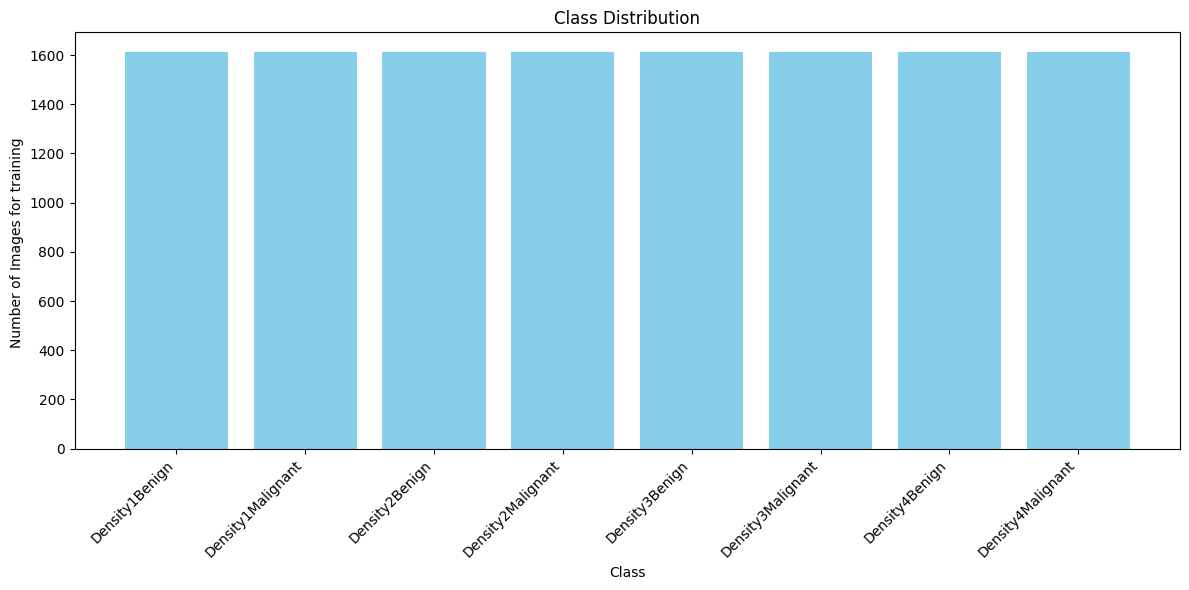

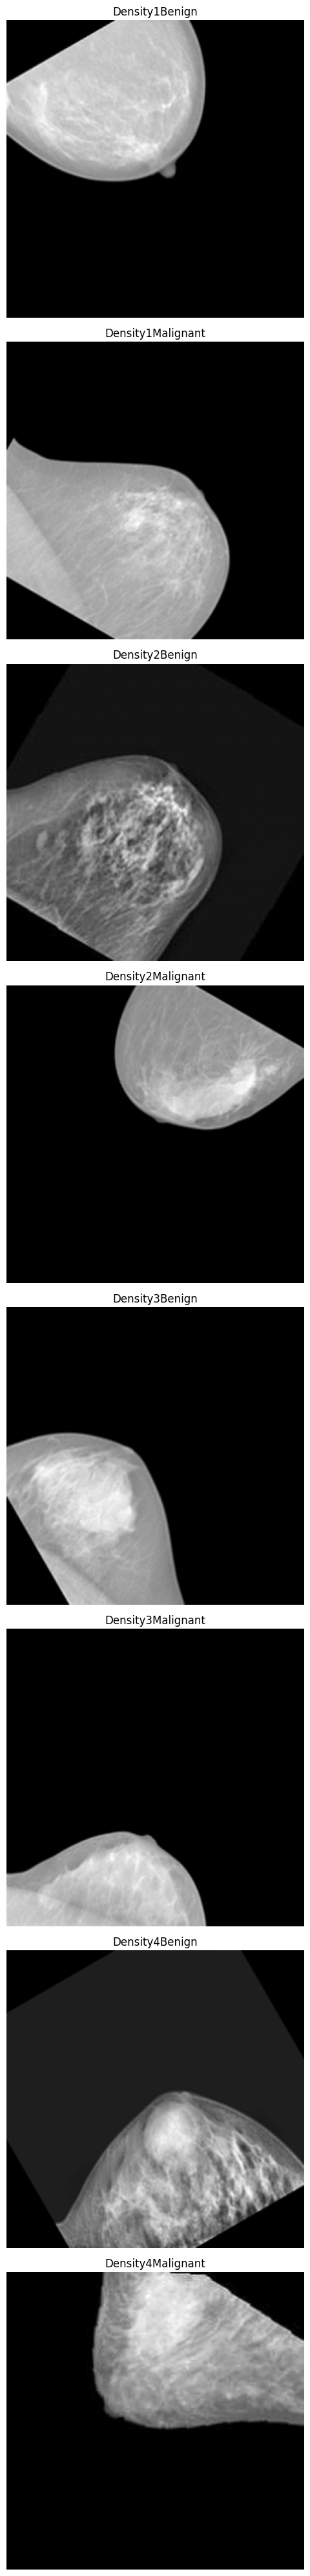

In [ ]:
import os
import matplotlib.pyplot as plt
from PIL import Image

# Define the directory containing the images
train_dir = '/content/splitted-dataset_resized/train'

# List of class names
classes = [
    'Density1Benign', 'Density1Malignant',
    'Density2Benign', 'Density2Malignant',
    'Density3Benign', 'Density3Malignant',
    'Density4Benign', 'Density4Malignant'
]

# Function to count images in each class
def count_images(image_dir, class_names):
    class_counts = {}

    for class_name in class_names:
        class_dir = os.path.join(image_dir, class_name)
        # Count the number of images in the directory
        num_images = len([f for f in os.listdir(class_dir) if f.endswith('.png') or f.endswith('.jpg')])
        class_counts[class_name] = num_images

    return class_counts

# Function to load and display sample images
def display_sample_images(image_dir, class_names, num_samples=1):
    num_classes = len(class_names)
    fig, axes = plt.subplots(num_classes, num_samples, figsize=(10, num_classes * 5))

    # Check if axes is a 2D array or 1D array
    if num_samples == 1:
        axes = axes.reshape((num_classes, num_samples))

    for i, class_name in enumerate(class_names):
        class_dir = os.path.join(image_dir, class_name)

        # Get all image files in the class directory
        image_files = [f for f in os.listdir(class_dir) if f.endswith('.png') or f.endswith('.jpg')]

        # Load and display sample images
        for j in range(num_samples):
            if j < len(image_files):  # Ensure we don't exceed the number of available images
                image_path = os.path.join(class_dir, image_files[j])
                image = Image.open(image_path)
                axes[i, j].imshow(image, cmap='gray')
                axes[i, j].axis('off')
                if j == 0:
                    axes[i, j].set_title(class_name)
            else:
                # Clear the axis if there is no image to display
                axes[i, j].axis('off')

    plt.tight_layout()
    plt.show()

# Count images in each class
class_counts = count_images(train_dir, classes)

# Plot the class distribution
plt.figure(figsize=(12, 6))
plt.bar(class_counts.keys(), class_counts.values(), color='skyblue')
plt.xlabel('Class')
plt.ylabel('Number of Images for training ')
plt.title('Class Distribution')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Display sample images for each class
display_sample_images(train_dir, classes)

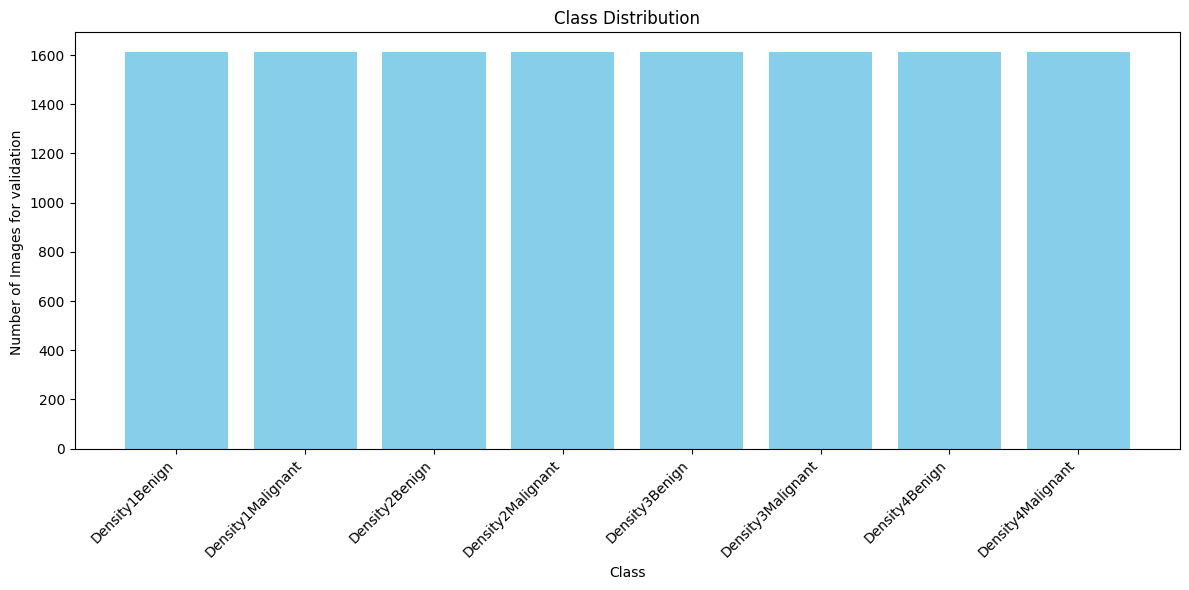

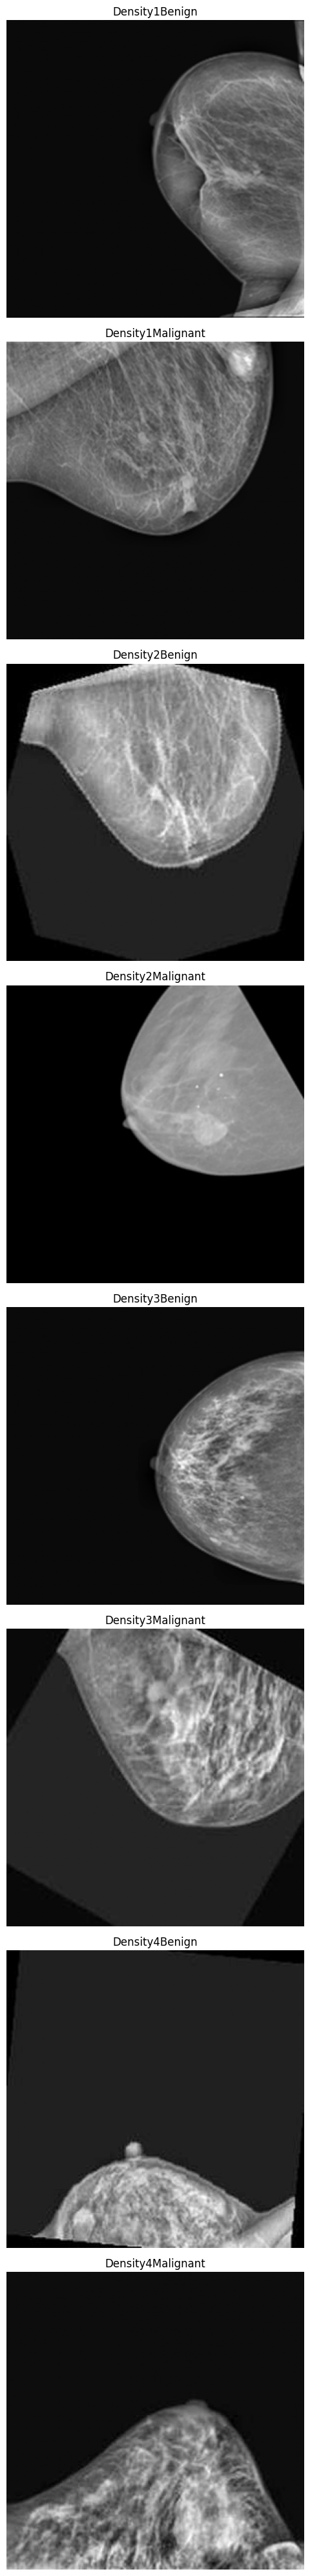

In [ ]:
import os
import matplotlib.pyplot as plt
from PIL import Image

# Define the directory containing the images
val_dir = "/content/splitted-dataset_resized/val"

# List of class names
classes = [
    'Density1Benign', 'Density1Malignant',
    'Density2Benign', 'Density2Malignant',
    'Density3Benign', 'Density3Malignant',
    'Density4Benign', 'Density4Malignant'
]

# Function to count images in each class
def count_images(image_dir, class_names):
    class_counts = {}

    for class_name in class_names:
        class_dir = os.path.join(image_dir, class_name)
        # Count the number of images in the directory
        num_images = len([f for f in os.listdir(class_dir) if f.endswith('.png') or f.endswith('.jpg')])
        class_counts[class_name] = num_images

    return class_counts

# Function to load and display sample images
def display_sample_images(image_dir, class_names, num_samples=1):
    num_classes = len(class_names)
    fig, axes = plt.subplots(num_classes, num_samples, figsize=(10, num_classes * 5))

    # Check if axes is a 2D array or 1D array
    if num_samples == 1:
        axes = axes.reshape((num_classes, num_samples))

    for i, class_name in enumerate(class_names):
        class_dir = os.path.join(image_dir, class_name)

        # Get all image files in the class directory
        image_files = [f for f in os.listdir(class_dir) if f.endswith('.png') or f.endswith('.jpg')]

        # Load and display sample images
        for j in range(num_samples):
            if j < len(image_files):  # Ensure we don't exceed the number of available images
                image_path = os.path.join(class_dir, image_files[j])
                image = Image.open(image_path)
                axes[i, j].imshow(image, cmap='gray')
                axes[i, j].axis('off')
                if j == 0:
                    axes[i, j].set_title(class_name)
            else:
                # Clear the axis if there is no image to display
                axes[i, j].axis('off')

    plt.tight_layout()
    plt.show()

# Count images in each class
class_counts = count_images(train_dir, classes)

# Plot the class distribution
plt.figure(figsize=(12, 6))
plt.bar(class_counts.keys(), class_counts.values(), color='skyblue')
plt.xlabel('Class')
plt.ylabel('Number of Images for validation ')
plt.title('Class Distribution')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Display sample images for each class
display_sample_images(val_dir, classes)

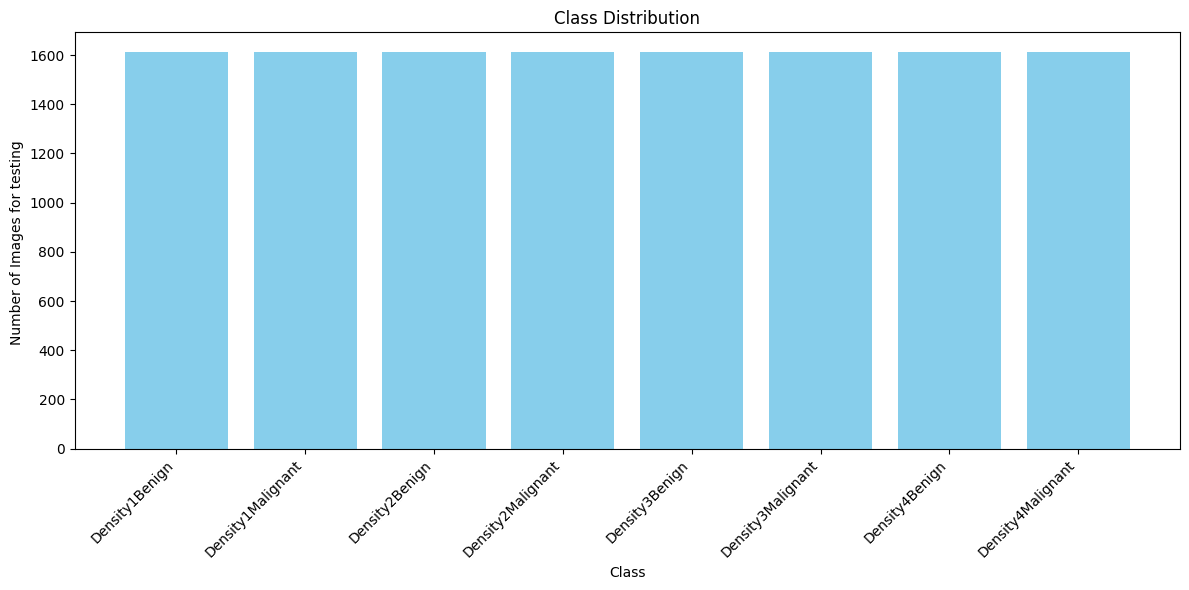

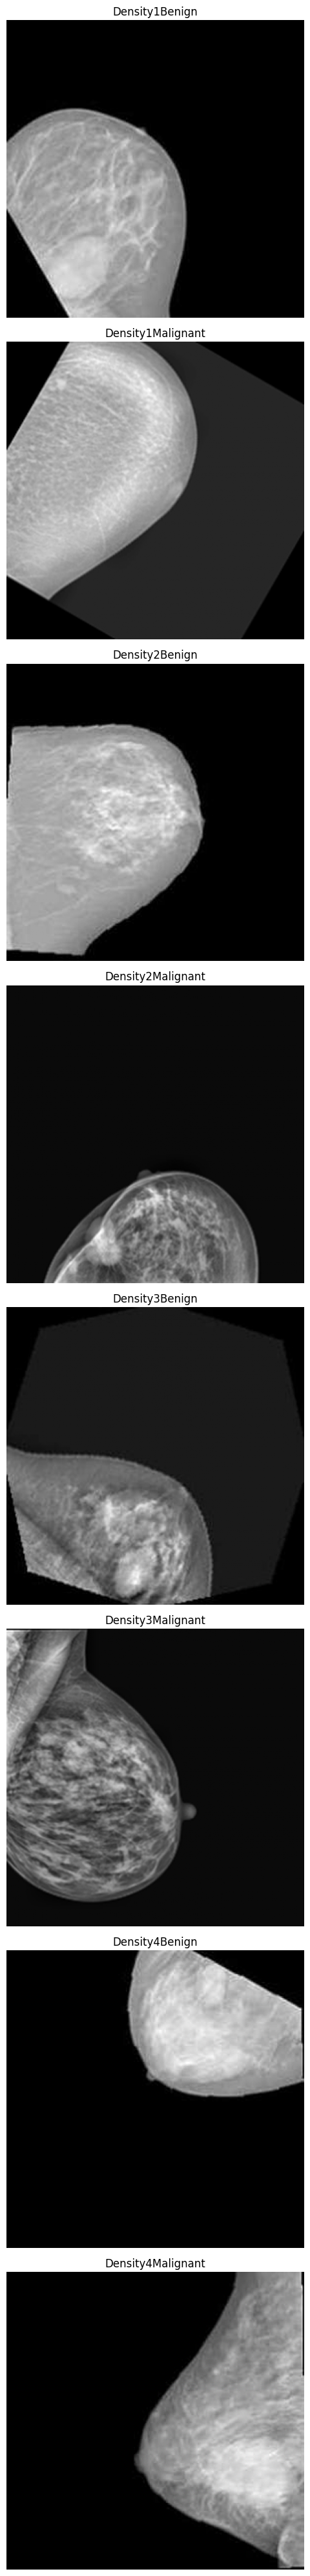

In [ ]:
import os
import matplotlib.pyplot as plt
from PIL import Image

# Define the directory containing the images
test_dir = "/content/splitted-dataset_resized/test"

# List of class names
classes = [
    'Density1Benign', 'Density1Malignant',
    'Density2Benign', 'Density2Malignant',
    'Density3Benign', 'Density3Malignant',
    'Density4Benign', 'Density4Malignant'
]

# Function to count images in each class
def count_images(image_dir, class_names):
    class_counts = {}

    for class_name in class_names:
        class_dir = os.path.join(image_dir, class_name)
        # Count the number of images in the directory
        num_images = len([f for f in os.listdir(class_dir) if f.endswith('.png') or f.endswith('.jpg')])
        class_counts[class_name] = num_images

    return class_counts

# Function to load and display sample images
def display_sample_images(image_dir, class_names, num_samples=1):
    num_classes = len(class_names)
    fig, axes = plt.subplots(num_classes, num_samples, figsize=(10, num_classes * 5))

    # Check if axes is a 2D array or 1D array
    if num_samples == 1:
        axes = axes.reshape((num_classes, num_samples))

    for i, class_name in enumerate(class_names):
        class_dir = os.path.join(image_dir, class_name)

        # Get all image files in the class directory
        image_files = [f for f in os.listdir(class_dir) if f.endswith('.png') or f.endswith('.jpg')]

        # Load and display sample images
        for j in range(num_samples):
            if j < len(image_files):  # Ensure we don't exceed the number of available images
                image_path = os.path.join(class_dir, image_files[j])
                image = Image.open(image_path)
                axes[i, j].imshow(image, cmap='gray')
                axes[i, j].axis('off')
                if j == 0:
                    axes[i, j].set_title(class_name)
            else:
                # Clear the axis if there is no image to display
                axes[i, j].axis('off')

    plt.tight_layout()
    plt.show()

# Count images in each class
class_counts = count_images(train_dir, classes)

# Plot the class distribution
plt.figure(figsize=(12, 6))
plt.bar(class_counts.keys(), class_counts.values(), color='skyblue')
plt.xlabel('Class')
plt.ylabel('Number of Images for testing ')
plt.title('Class Distribution')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Display sample images for each class
display_sample_images(test_dir, classes)

Found 12896 images belonging to 8 classes.


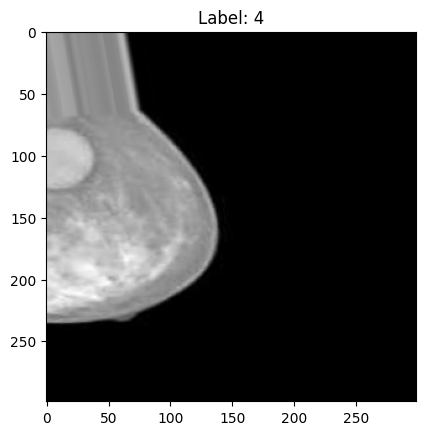

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np

# Image size and batch size
img_size = (299, 299)
batch_size = 32

# Data generator with consistent preprocessing for both training and validation
data_gen = ImageDataGenerator(
    rescale=1./255,          # Apply rescaling to both training and validation
    rotation_range=30,
    width_shift_range=0.3,
    height_shift_range=0.3,
    shear_range=0.3,
    zoom_range=0.3,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Training data generator
train_dir = '/content/splitted-dataset_resized/train'
try:
    train_generator = data_gen.flow_from_directory(
        train_dir,
        target_size=img_size,
        color_mode='grayscale',
        batch_size=batch_size,
        class_mode='categorical',
        shuffle=True
    )
except FileNotFoundError:
    print(f"Directory not found: {train_dir}")
    train_generator = None

# Check if train_generator is successfully defined
if train_generator:
    # Fetch a batch
    train_batch, train_labels = next(train_generator)
    # Display the first image in the batch
    plt.imshow(train_batch[0].reshape(299, 299), cmap='gray')
    plt.title(f"Label: {np.argmax(train_labels[0])}")
    plt.show()
else:
    print("Training generator not defined. Please verify the dataset path and structure.")


In [ ]:
# Function to count images in each class
def count_images(train_dir, class_names):
    class_counts = {}

    for class_name in class_names:
        class_dir = os.path.join(train_dir, class_name)
        # Count the number of images in the directory
        num_images = len([f for f in os.listdir(class_dir) if f.endswith('.png') or f.endswith('.jpg')])
        class_counts[class_name] = num_images

    return class_counts
# Count images in each class
class_counts = count_images(train_dir, classes)
print(class_counts)

{'Density1Benign': 1612, 'Density1Malignant': 1612, 'Density2Benign': 1612, 'Density2Malignant': 1612, 'Density3Benign': 1612, 'Density3Malignant': 1612, 'Density4Benign': 1612, 'Density4Malignant': 1612}


In [ ]:
# Function to count images in each class
def count_images(val_dir, class_names):
    class_counts = {}

    for class_name in class_names:
        class_dir = os.path.join(val_dir, class_name)
        # Count the number of images in the directory
        num_images = len([f for f in os.listdir(class_dir) if f.endswith('.png') or f.endswith('.jpg')])
        class_counts[class_name] = num_images

    return class_counts
# Count images in each class
class_counts = count_images(val_dir, classes)
print(class_counts)

{'Density1Benign': 461, 'Density1Malignant': 461, 'Density2Benign': 461, 'Density2Malignant': 461, 'Density3Benign': 461, 'Density3Malignant': 461, 'Density4Benign': 461, 'Density4Malignant': 461}


In [ ]:
# Function to count images in each class
def count_images(test_dir, class_names):
    class_counts = {}

    for class_name in class_names:
        class_dir = os.path.join(test_dir, class_name)
        # Count the number of images in the directory
        num_images = len([f for f in os.listdir(class_dir) if f.endswith('.png') or f.endswith('.jpg')])
        class_counts[class_name] = num_images

    return class_counts
# Count images in each class
class_counts = count_images(test_dir, classes)
print(class_counts)

{'Density1Benign': 231, 'Density1Malignant': 231, 'Density2Benign': 231, 'Density2Malignant': 231, 'Density3Benign': 231, 'Density3Malignant': 231, 'Density4Benign': 231, 'Density4Malignant': 231}


In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation, MaxPooling2D, concatenate, GlobalAveragePooling2D, Dense, Input, Layer
from tensorflow.keras.models import Model
from tensorflow.keras import optimizers

# Inception-A Block
def inception_v4_block_A(x):
    branch_1x1 = Conv2D(96, (1, 1), padding='same')(x)
    branch_1x1 = BatchNormalization()(branch_1x1)
    branch_1x1 = Activation('relu')(branch_1x1)

    branch_3x3 = Conv2D(64, (1, 1), padding='same')(x)
    branch_3x3 = BatchNormalization()(branch_3x3)
    branch_3x3 = Activation('relu')(branch_3x3)
    branch_3x3 = Conv2D(96, (3, 3), padding='same')(branch_3x3)
    branch_3x3 = BatchNormalization()(branch_3x3)
    branch_3x3 = Activation('relu')(branch_3x3)

    branch_5x5 = Conv2D(64, (1, 1), padding='same')(x)
    branch_5x5 = BatchNormalization()(branch_5x5)
    branch_5x5 = Activation('relu')(branch_5x5)
    branch_5x5 = Conv2D(96, (5, 5), padding='same')(branch_5x5)
    branch_5x5 = BatchNormalization()(branch_5x5)
    branch_5x5 = Activation('relu')(branch_5x5)

    branch_pool = MaxPooling2D((3, 3), strides=(1, 1), padding='same')(x)
    branch_pool = Conv2D(96, (1, 1), padding='same')(branch_pool)
    branch_pool = BatchNormalization()(branch_pool)
    branch_pool = Activation('relu')(branch_pool)

    x = concatenate([branch_1x1, branch_3x3, branch_5x5, branch_pool], axis=-1)
    return x

# Locality Preserving Projection Layer
class LocalityPreservingProjection(Layer):
    def __init__(self, output_dim, **kwargs):
        super(LocalityPreservingProjection, self).__init__(**kwargs)
        self.output_dim = output_dim

    def build(self, input_shape):
        self.kernel = self.add_weight(name='kernel', shape=(input_shape[-1], self.output_dim), initializer='uniform', trainable=True)

    def call(self, inputs):
        projected = tf.matmul(inputs, self.kernel)
        return projected

# Inception-v4 Model
def inception_v4(input_shape, num_classes):
    inputs = Input(shape=input_shape)

    # Stem block
    x = Conv2D(32, (3, 3), strides=(2, 2), padding='same')(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = Conv2D(32, (3, 3), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = Conv2D(64, (3, 3), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)

    x = Conv2D(80, (1, 1), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = Conv2D(192, (3, 3), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)

    # Inception-A blocks
    for _ in range(4):
        x = inception_v4_block_A(x)

    # Reduction-A block
    x = Conv2D(384, (3, 3), strides=(2, 2), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    # Final pooling and output
    x = GlobalAveragePooling2D()(x)

    # Locality Preserving Projection
    lpp = LocalityPreservingProjection(output_dim=8)(x)

    # Dense output layer
    outputs = Dense(num_classes, activation='softmax')(lpp)

    model = Model(inputs, outputs, name='Inception-v4-LPP')
    return model

def preprocess_input(image):
    # If the input is grayscale, repeat channels to convert to RGB
    if image.shape[-1] == 1:
        image = np.repeat(image, 3, axis=-1)
    return image

# Parameters
input_shape = (299, 299, 1)
num_classes = 8

# Create and compile model
model = inception_v4(input_shape, num_classes)
optimizer = optimizers.Adam(learning_rate=1e-4, clipnorm=1.0)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()


Model: "Inception-v4-LPP"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_30 (Conv2D)  │ (None, 150, 150,  │        320 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 150, 150,  │        128 │ conv2d_30[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_30       │ (None, 150, 150,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_31 (Conv2D)  │ (None, 150, 150,  │      9,248 │ activation_30[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 150, 150,  │        128 │ conv2d_31[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_31       │ (None, 150, 150,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_32 (Conv2D)  │ (None, 150, 150,  │     18,496 │ activation_31[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 150, 150,  │        256 │ conv2d_32[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_32       │ (None, 150, 150,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 75, 75,    │          0 │ activation_32[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_33 (Conv2D)  │ (None, 75, 75,    │      5,200 │ max_pooling2d_6[… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 75, 75,    │        320 │ conv2d_33[0][0]   │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_33       │ (None, 75, 75,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_34 (Conv2D)  │ (None, 75, 75,    │    138,432 │ activation_33[0]… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 75, 75,    │        768 │ conv2d_34[0][0]   │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_34       │ (None, 75, 75,    │          0 │ batch_normalizat

 Total params: 2,781,368 (10.61 MB)

 Trainable params: 2,775,704 (10.59 MB)

 Non-trainable params: 5,664 (22.12 KB)

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt
import os


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Image size and batch size
img_size = (299, 299)  # ONLY height and width, no channel dimension here
batch_size = 32

# Data generator with consistent preprocessing for both training and validation
data_gen = ImageDataGenerator(
    rescale=1./255,          # Apply rescaling to both training and validation
    rotation_range=30,
    width_shift_range=0.3,
    height_shift_range=0.3,
    shear_range=0.3,
    zoom_range=0.3,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Training data generator
train_generator = data_gen.flow_from_directory(
    '/content/splitted-dataset_resized/train',
    target_size=img_size,    # Correct shape here
    color_mode='grayscale',
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

# Validation data generator
validation_generator = data_gen.flow_from_directory(
    '/content/splitted-dataset_resized/val',
    target_size=img_size,    # Correct shape here too
    color_mode='grayscale',
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)


Found 12896 images belonging to 8 classes.
Found 3688 images belonging to 8 classes.


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define the test data directory
test_dir = '/content/splitted-dataset_resized/test'

# Define image size and batch size (same as train/validation)
img_size = (299, 299)
batch_size = 128

# Create test data generator with only rescaling
test_datagen = ImageDataGenerator(rescale=1./255)

# Create test data generator (no shuffle for test)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    color_mode='grayscale',
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)


Found 1848 images belonging to 8 classes.


In [ ]:
from tensorflow.keras.optimizers import Adam

# Adjust the optimizer
optimizer = Adam(learning_rate=1e-4)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

In [ ]:
# Train the model
history = model.fit(
    train_generator,
    epochs=30,
    validation_data=validation_generator,
    callbacks=[early_stopping, reduce_lr]
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 220s 428ms/step - accuracy: 0.2887 - loss: 1.8738 - val_accuracy: 0.2091 - val_loss: 2.3912 - learning_rate: 1.0000e-04
Epoch 2/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 166s 412ms/step - accuracy: 0.5402 - loss: 1.3544 - val_accuracy: 0.5014 - val_loss: 1.3618 - learning_rate: 1.0000e-04
Epoch 3/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 200s 407ms/step - accuracy: 0.6461 - loss: 1.0670 - val_accuracy: 0.6429 - val_loss: 1.0159 - learning_rate: 1.0000e-04
Epoch 4/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 165s 408ms/step - accuracy: 0.6892 - loss: 0.8852 - val_accuracy: 0.6318 - val_loss: 1.0705 - learning_rate: 1.0000e-04
Epoch 5/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 164s 406ms/step - accuracy: 0.7609 - loss: 0.7139 - val_accuracy: 0.5160 - val_loss: 1.6882 - learning_rate: 1.0000e-04
Epoch 6/30
403/403 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step - accuracy: 0.8082 - loss: 0.5791
Epoch 6: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
403/403 ━━━━━━━━━━━━━━━━━━━━ 163s 40

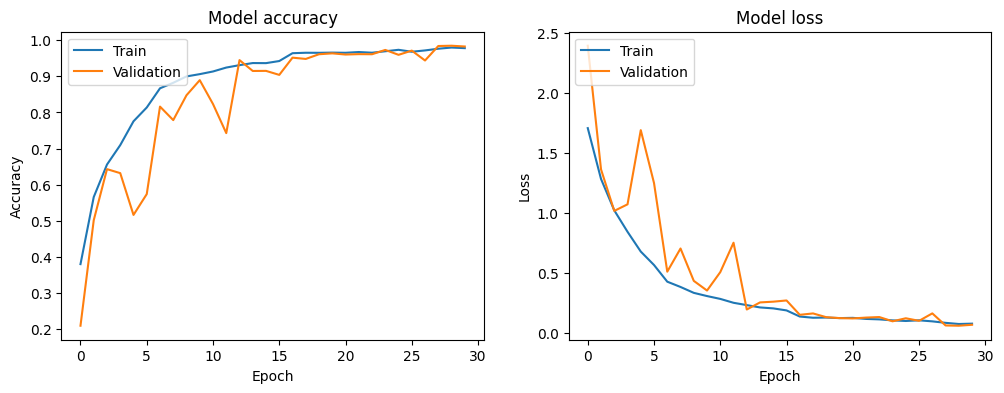

In [ ]:
# Plotting the learning curve

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.show()

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import tensorflow as tf
# Make predictions on the validation data
validation_generator.reset()  # Reset the generator before making predictions
predictions = model.predict(validation_generator)
predicted_classes = np.argmax(predictions, axis=1)

# True labels
true_classes = validation_generator.classes

# Get class labels
class_labels = list(validation_generator.class_indices.keys())

# Classification report
report = classification_report(true_classes, predicted_classes, target_names=class_labels)
print("Classification Report:\n", report)


116/116 ━━━━━━━━━━━━━━━━━━━━ 34s 277ms/step
Classification Report:
                    precision    recall  f1-score   support

   Density1Benign       0.99      0.98      0.99       461
Density1Malignant       0.98      0.98      0.98       461
   Density2Benign       1.00      0.99      1.00       461
Density2Malignant       0.95      0.98      0.97       461
   Density3Benign       0.99      0.98      0.99       461
Density3Malignant       1.00      0.96      0.98       461
   Density4Benign       0.97      1.00      0.98       461
Density4Malignant       1.00      1.00      1.00       461

         accuracy                           0.98      3688
        macro avg       0.98      0.98      0.98      3688
     weighted avg       0.98      0.98      0.98      3688



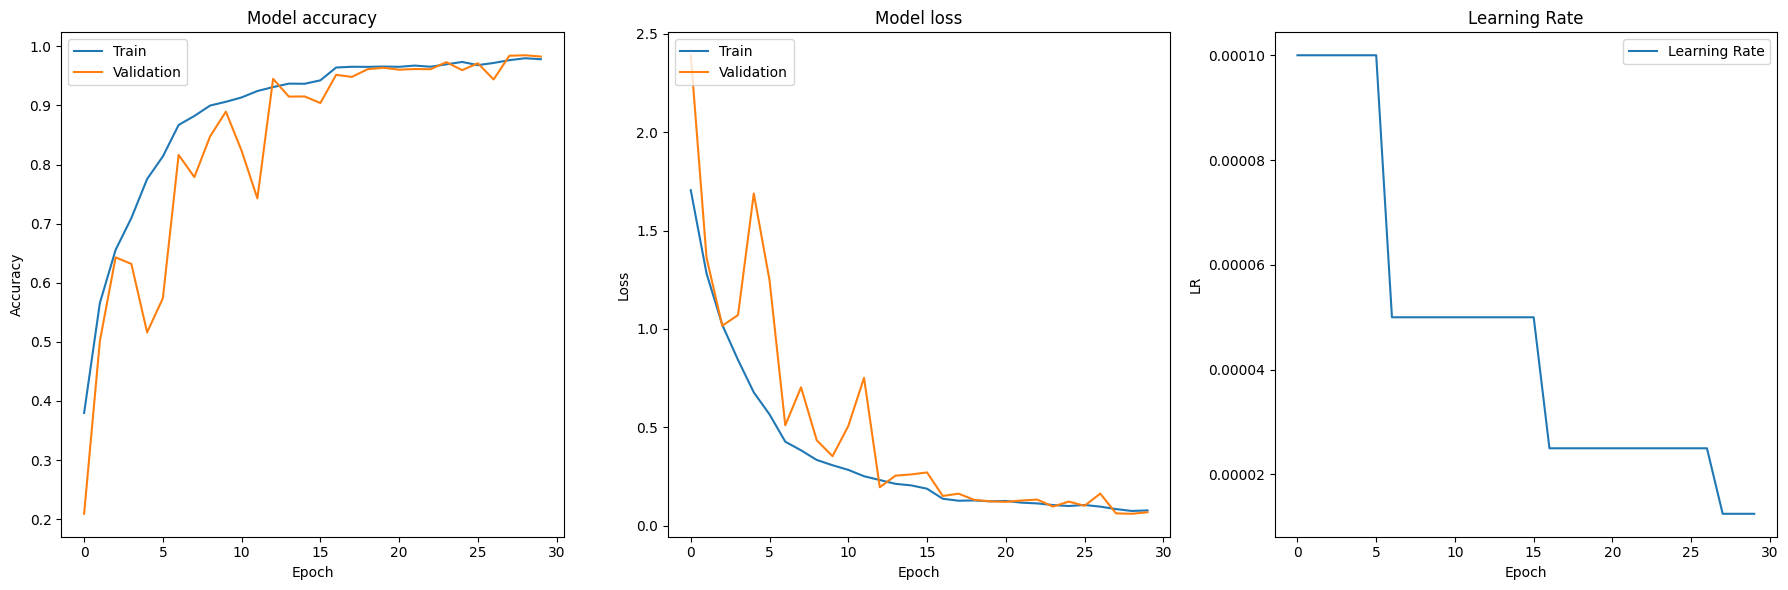

In [ ]:
# Plotting the learning curve including learning rate

import matplotlib.pyplot as plt

plt.figure(figsize=(18, 6))

# Plot training & validation accuracy values
plt.subplot(1, 3, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 3, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot learning rate
plt.subplot(1, 3, 3)
# Check if 'lr' or 'learning_rate' is in history keys
if 'lr' in history.history:
    plt.plot(history.history['lr'])
    plt.title('Learning Rate')
    plt.ylabel('LR')
    plt.xlabel('Epoch')
    plt.legend(['Learning Rate'], loc='upper right')
elif 'learning_rate' in history.history:
     plt.plot(history.history['learning_rate'])
     plt.title('Learning Rate')
     plt.ylabel('LR')
     plt.xlabel('Epoch')
     plt.legend(['Learning Rate'], loc='upper right')
else:
    print("Learning rate history not found in history.history. Available keys:")
    print(history.history.keys())


plt.tight_layout()
plt.show()

In [ ]:
# Evaluate the model on the validation set
val_loss, val_accuracy = model.evaluate(validation_generator)
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")

116/116 ━━━━━━━━━━━━━━━━━━━━ 35s 305ms/step - accuracy: 0.9748 - loss: 0.0777
Validation Accuracy: 98.10%


In [ ]:
# Confusion matrix
conf_matrix = confusion_matrix(true_classes, predicted_classes)
print("Confusion Matrix:\n", conf_matrix)

Confusion Matrix:
 [[452   2   0   5   1   0   1   0]
 [  0 451   0   9   0   1   0   0]
 [  2   0 458   1   0   0   0   0]
 [  1   5   0 452   0   0   3   0]
 [  1   0   0   4 453   0   3   0]
 [  0   4   0   3   4 444   6   0]
 [  0   0   0   1   0   1 459   0]
 [  0   0   0   0   0   0   0 461]]


In [ ]:
# Summarize precision, recall, and f1-score
precision = report.split()[-4]
recall = report.split()[-3]  # Recall is also sensitivity
f1_score = report.split()[-2]

print(f"Accuracy: {val_accuracy * 100:.2f}%")
print(f"Precision: {precision}")
print(f"Recall (Sensitivity): {recall}")
print(f"F1-Score: {f1_score}")


Accuracy: 98.10%
Precision: 0.98
Recall (Sensitivity): 0.98
F1-Score: 0.98


In [ ]:
model.save("/content/drive/MyDrive/saved_models/Inception_V4_with_LPP.h5")

NameError: name 'model' is not defined

In [ ]:
# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"test Accuracy: {test_accuracy * 100:.2f}%")

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


15/15 ━━━━━━━━━━━━━━━━━━━━ 30s 884ms/step - accuracy: 0.9907 - loss: 0.0368
test Accuracy: 99.51%


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import tensorflow as tf
# Make predictions on the validation data
test_generator.reset()  # Reset the generator before making predictions
predictions = model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)

# True labels
true_classes = test_generator.classes

# Get class labels
class_labels = list(test_generator.class_indices.keys())

# Classification report
report = classification_report(true_classes, predicted_classes, target_names=class_labels)
print("Classification Report:\n", report)

15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 382ms/step
Classification Report:
                    precision    recall  f1-score   support

   Density1Benign       1.00      0.98      0.99       231
Density1Malignant       1.00      0.99      0.99       231
   Density2Benign       0.99      1.00      0.99       231
Density2Malignant       0.99      1.00      0.99       231
   Density3Benign       1.00      1.00      1.00       231
Density3Malignant       1.00      1.00      1.00       231
   Density4Benign       1.00      1.00      1.00       231
Density4Malignant       1.00      1.00      1.00       231

         accuracy                           1.00      1848
        macro avg       1.00      1.00      1.00      1848
     weighted avg       1.00      1.00      1.00      1848



In [ ]:
# Confusion matrix
conf_matrix = confusion_matrix(true_classes, predicted_classes)
print("Confusion Matrix:\n", conf_matrix)

Confusion Matrix:
 [[226   1   3   0   0   1   0   0]
 [  0 229   0   2   0   0   0   0]
 [  0   0 231   0   0   0   0   0]
 [  0   0   0 231   0   0   0   0]
 [  0   0   0   1 230   0   0   0]
 [  0   0   0   0   1 230   0   0]
 [  0   0   0   0   0   0 231   0]
 [  0   0   0   0   0   0   0 231]]


In [ ]:
# Summarize precision, recall, and f1-score
precision = report.split()[-4]
recall = report.split()[-3]  # Recall is also sensitivity
f1_score = report.split()[-2]

print(f"Accuracy: {test_accuracy * 100:.2f}%")
print(f"Precision: {precision}")
print(f"Recall (Sensitivity): {recall}")
print(f"F1-Score: {f1_score}")


Accuracy: 99.51%
Precision: 1.00
Recall (Sensitivity): 1.00
F1-Score: 1.00
